In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install seaborn scikit-learn

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
BASE_PATH = "/content/drive/MyDrive/final_dataset"

EYE_TRAIN = BASE_PATH + "/eyes/train"
EYE_VAL   = BASE_PATH + "/eyes/val"
EYE_TEST  = BASE_PATH + "/eyes/test"

MOUTH_TRAIN = BASE_PATH + "/mouth/train"
MOUTH_VAL   = BASE_PATH + "/mouth/val"
MOUTH_TEST  = BASE_PATH + "/mouth/test"

IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 10

In [ ]:
eye_datagen = ImageDataGenerator(rescale=1./255)

eye_train = eye_datagen.flow_from_directory(
    EYE_TRAIN,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="binary",
    batch_size=BATCH_SIZE
)

eye_val = eye_datagen.flow_from_directory(
    EYE_VAL,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="binary",
    batch_size=BATCH_SIZE
)

eye_test = eye_datagen.flow_from_directory(
    EYE_TEST,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="binary",
    batch_size=1,
    shuffle=False
)

print("Eye classes:", eye_train.class_indices)

Found 1814 images belonging to 2 classes.
Found 388 images belonging to 2 classes.
Found 390 images belonging to 2 classes.
Eye classes: {'eyes_closed': 0, 'eyes_open': 1}


In [ ]:
eye_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

eye_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

eye_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,624,705 (6.20 MB)

 Trainable params: 1,624,705 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_eye = eye_model.fit(
    eye_train,
    validation_data=eye_val,
    epochs=EPOCHS
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 630s 11s/step - accuracy: 0.8501 - loss: 0.3528 - val_accuracy: 0.9794 - val_loss: 0.0738
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 330ms/step - accuracy: 0.9901 - loss: 0.0401 - val_accuracy: 0.9871 - val_loss: 0.0467
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 319ms/step - accuracy: 0.9912 - loss: 0.0278 - val_accuracy: 0.9948 - val_loss: 0.0201
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 313ms/step - accuracy: 0.9961 - loss: 0.0127 - val_accuracy: 0.9948 - val_loss: 0.0131
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 316ms/step - accuracy: 0.9989 - loss: 0.0074 - val_accuracy: 0.9948 - val_loss: 0.0173
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 315ms/step - accuracy: 0.9994 - loss: 0.0040 - val_accuracy: 0.9948 - val_loss: 0.0098
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 312ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9897 - val_loss: 0.0214
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 318ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accur

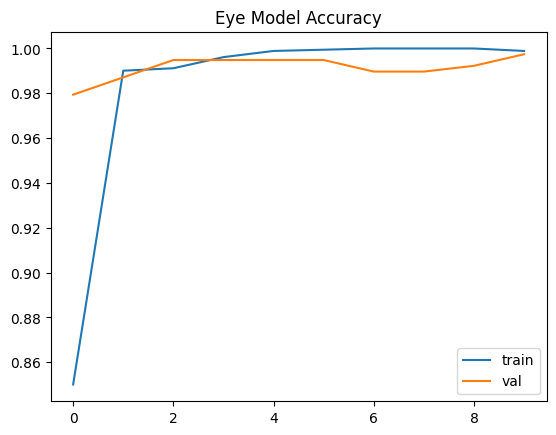

In [ ]:
plt.plot(history_eye.history['accuracy'], label='train')
plt.plot(history_eye.history['val_accuracy'], label='val')
plt.title("Eye Model Accuracy")
plt.legend()
plt.show()

390/390 ━━━━━━━━━━━━━━━━━━━━ 182s 466ms/step


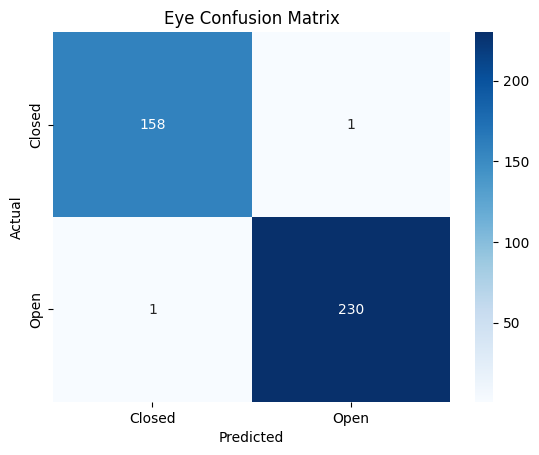

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       159
           1       1.00      1.00      1.00       231

    accuracy                           0.99       390
   macro avg       0.99      0.99      0.99       390
weighted avg       0.99      0.99      0.99       390



In [ ]:
y_true = eye_test.classes
y_pred = (eye_model.predict(eye_test) > 0.5).astype("int32").flatten()

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Closed", "Open"],
            yticklabels=["Closed", "Open"])
plt.title("Eye Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred))

In [ ]:
eye_model.save("/content/eye_model.keras")

In [ ]:
mouth_datagen = ImageDataGenerator(rescale=1./255)

mouth_train = mouth_datagen.flow_from_directory(
    MOUTH_TRAIN,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="binary",
    batch_size=BATCH_SIZE
)

mouth_val = mouth_datagen.flow_from_directory(
    MOUTH_VAL,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="binary",
    batch_size=BATCH_SIZE
)

mouth_test = mouth_datagen.flow_from_directory(
    MOUTH_TEST,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="binary",
    batch_size=1,
    shuffle=False
)

print("Mouth classes:", mouth_train.class_indices)

Found 1631 images belonging to 2 classes.
Found 348 images belonging to 2 classes.
Found 352 images belonging to 2 classes.
Mouth classes: {'mouth_closed': 0, 'mouth_open': 1}


In [ ]:
mouth_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

mouth_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mouth_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,624,705 (6.20 MB)

 Trainable params: 1,624,705 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_mouth = mouth_model.fit(
    mouth_train,
    validation_data=mouth_val,
    epochs=EPOCHS
)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 549s 11s/step - accuracy: 0.8584 - loss: 0.3283 - val_accuracy: 0.9655 - val_loss: 0.1216
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 326ms/step - accuracy: 0.9767 - loss: 0.0790 - val_accuracy: 0.9741 - val_loss: 0.0792
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 325ms/step - accuracy: 0.9945 - loss: 0.0320 - val_accuracy: 0.9856 - val_loss: 0.0393
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 321ms/step - accuracy: 0.9969 - loss: 0.0122 - val_accuracy: 0.9828 - val_loss: 0.0403
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 322ms/step - accuracy: 0.9975 - loss: 0.0110 - val_accuracy: 0.9856 - val_loss: 0.0373
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 326ms/step - accuracy: 0.9969 - loss: 0.0126 - val_accuracy: 0.9856 - val_loss: 0.0523
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 323ms/step - accuracy: 0.9988 - loss: 0.0053 - val_accuracy: 0.9856 - val_loss: 0.0561
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 20s 319ms/step - accuracy: 0.9982 - loss: 0.0043 - val_accur

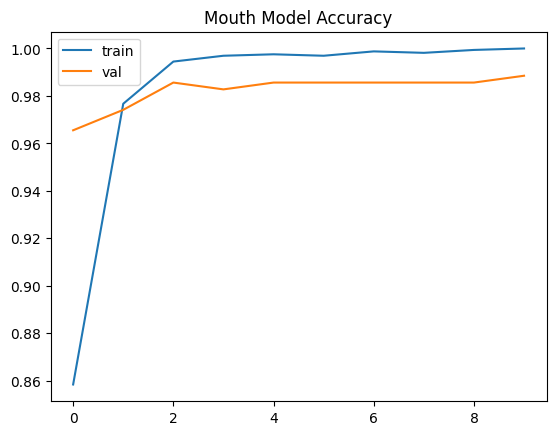

In [ ]:
plt.plot(history_mouth.history['accuracy'], label='train')
plt.plot(history_mouth.history['val_accuracy'], label='val')
plt.title("Mouth Model Accuracy")
plt.legend()
plt.show()

352/352 ━━━━━━━━━━━━━━━━━━━━ 149s 423ms/step


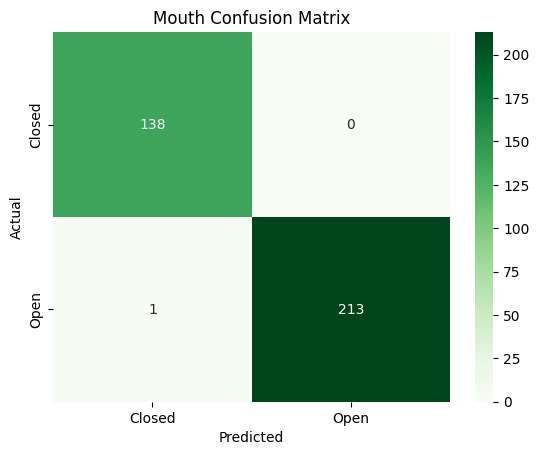

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       138
           1       1.00      1.00      1.00       214

    accuracy                           1.00       352
   macro avg       1.00      1.00      1.00       352
weighted avg       1.00      1.00      1.00       352



In [ ]:
y_true = mouth_test.classes
y_pred = (mouth_model.predict(mouth_test) > 0.5).astype("int32").flatten()

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Closed", "Open"],
            yticklabels=["Closed", "Open"])
plt.title("Mouth Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred))

In [ ]:
mouth_model.save("/content/mouth_model.keras")

In [ ]:
from google.colab import files

files.download("/content/eye_model.keras")
files.download("/content/mouth_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>